# *ASSIGNMENT-2: Network robustness*

In [22]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random
from itertools import combinations

In [23]:
BASE_DIR = Path().resolve().parent
DATASET_PATH = BASE_DIR / "data" / "anime_filtered.csv"
df = pd.read_csv(DATASET_PATH)

In [24]:
def build_graph(filtered):
    G = nx.Graph()
    for _, row in filtered.iterrows():
        G.add_node(row["mal_id"], title=row["title"])
    for (_, a), (_, b) in combinations(filtered.iterrows(), 2):
        genres_a = set(str(a["genres"]).split("|"))
        genres_b = set(str(b["genres"]).split("|"))
        if len(genres_a & genres_b) >= 2:
            G.add_edge(a["mal_id"], b["mal_id"])
    return G

In [25]:
G = build_graph(filtered=df)
print(G.number_of_nodes())
print(G.number_of_edges())

3579
780393


In [26]:
def giant_component(G):
    if G.number_of_nodes() == 0:
        return 0, G

    largest = max(nx.connected_components(G), key=len)
    return len(largest), G.subgraph(largest).copy()

In [27]:
def attack(G, strategy, step=0.05):
    G = G.copy()
    N = G.number_of_nodes()
    results = []

    while len(results) < int(1 / step):
        if G.number_of_nodes() == 0:
            results.append(0)
            continue
        remove_number = min(max(1, int(G.number_of_nodes() * step)), G.number_of_nodes())
        if strategy == "random":
            nodes = random.sample(list(G.nodes()), remove_number)
        elif strategy == "degree":
            nodes = [
                n for n, d in
                sorted(G.degree(), key=lambda x: x[1], reverse=True)[:remove_number]
            ]
        elif strategy == "pagerank":
            pr = nx.pagerank(G)
            nodes = sorted(pr, key=pr.get, reverse=True)[:remove_number]
        elif strategy == "betweenness":
            k = min(500, G.number_of_nodes())
            bc = nx.betweenness_centrality(G, k=k)
            nodes = sorted(bc, key=bc.get, reverse=True)[:remove_number]
        G.remove_nodes_from(nodes)
        size, G = giant_component(G)
        results.append(size / N)
    return results

## Testing on a NetworkX synthetic graph

In [28]:
G_test = nx.barabasi_albert_graph(
    n=500,
    m=3,
    seed=42
)

print("Test graph")
print("Nodes:", G_test.number_of_nodes())
print("Edges:", G_test.number_of_edges())

Test graph
Nodes: 500
Edges: 1491


In [29]:
random_test = attack(G_test, "random")
degree_test = attack(G_test, "degree")
pagerank_test = attack(G_test, "pagerank")
betweenness_test = attack(G_test, "betweenness")

In [ ]:
print(len(random_test))
print(len(degree_test))
print(len(pagerank_test))
print(len(betweenness_test))

In [ ]:
x_test = [i * 0.05 for i in range(1, 21)]

plt.figure(figsize=(10,6))

plt.plot(x_test, random_test, label="Random")
plt.plot(x_test, degree_test, label="Degree")
plt.plot(x_test, pagerank_test, label="PageRank")
plt.plot(x_test, betweenness_test, label="Betweenness")

plt.xlabel("Fraction of removed nodes")
plt.ylabel("G/N")
plt.title("Robustness analysis on Barabási-Albert graph")

plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [11]:
def critical_threshold(G):
    degrees = [d for _, d in G.degree()]
    k1 = sum(degrees) / len(degrees)
    k2 = sum(d*d for d in degrees) / len(degrees)
    fc = 1 - 1 / ((k2 / k1) - 1)
    return k1, k2, fc

In [14]:
random_result = attack(G, "random")
degree_result = attack(G, "degree")
pagerank_result = attack(G, "pagerank")
betweenness_result = attack(G, "betweenness")

In [15]:
print(len(random_result))
print(len(degree_result))
print(len(pagerank_result))
print(len(betweenness_result))

20
20
20
20


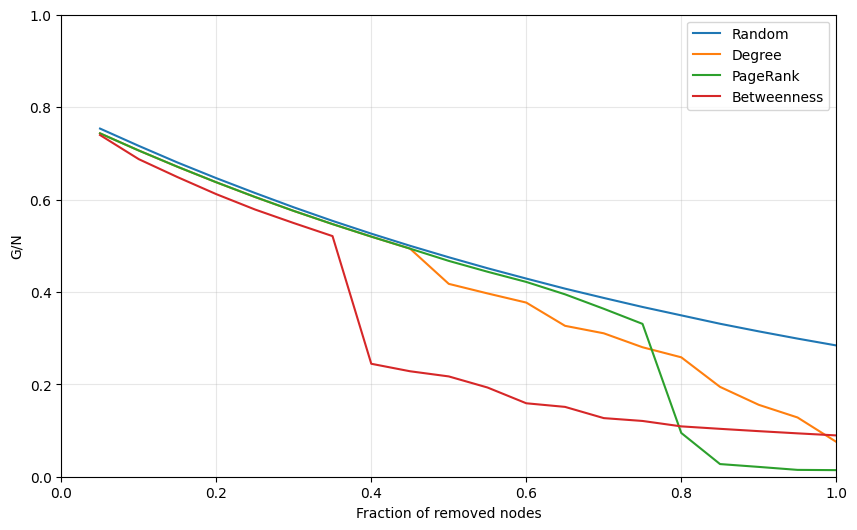

In [16]:
plt.figure(figsize=(10,6))

x = [i*0.05 for i in range(1, 21)]

plt.plot(x, random_result, label="Random")
plt.plot(x, degree_result, label="Degree")
plt.plot(x, pagerank_result, label="PageRank")
plt.plot(x, betweenness_result, label="Betweenness")

plt.xlabel("Fraction of removed nodes")
plt.ylabel("G/N")
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Improved

In [17]:
G_improved = G.copy()
top_nodes = sorted(
    G_improved.degree(),
    key=lambda x: x[1],
    reverse=True
)[:3]

for node, degree in top_nodes:
    neighbors = list(G_improved.neighbors(node))
    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):
            if not G_improved.has_edge(neighbors[i], neighbors[j]):
                G_improved.add_edge(neighbors[i], neighbors[j])

print("Nodes:", G_improved.number_of_nodes())
print("Edges:", G_improved.number_of_edges())

Nodes: 3579
Edges: 1720329


In [18]:
k1, k2, fc = critical_threshold(G_improved)

print("First moment:", k1)
print("Second moment:", k2)
print("Critical threshold:", fc)

First moment: 961.3461860854987
Second moment: 1656735.8178262084
Critical threshold: 0.9994193978693648


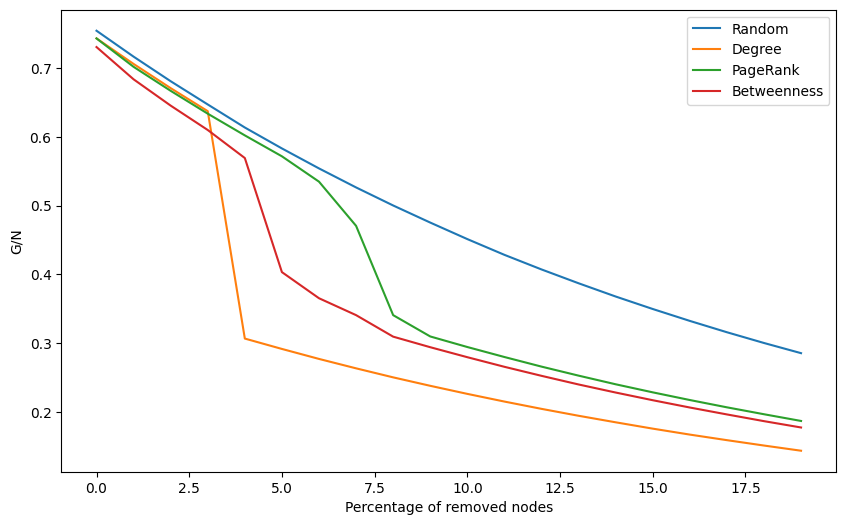

In [ ]:
random_result_improved = attack(G_improved, "random")
degree_result_improved = attack(G_improved, "degree")
pagerank_result_improved = attack(G_improved, "pagerank")
betweenness_result_improved = attack(G_improved, "betweenness")

In [ ]:
print(len(random_result_improved))
print(len(degree_result_improved))
print(len(pagerank_result_improved))
print(len(betweenness_result_improved))

In [ ]:
x = [i*0.05 for i in range(1,21)]

plt.figure(figsize=(10,6))

plt.plot(x, random_result_improved, label="Random")
plt.plot(x, degree_result_improved, label="Degree")
plt.plot(x, pagerank_result_improved, label="PageRank")
plt.plot(x, betweenness_result_improved, label="Betweenness")

plt.xlabel("Fraction of removed nodes")
plt.ylabel("G/N")
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [20]:
G_betweenness = G.copy()
bc = nx.betweenness_centrality(G_betweenness)
top_nodes = sorted(bc, key=bc.get, reverse=True)[:3]

for node in top_nodes:
    neighbors = list(G_betweenness.neighbors(node))
    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):
            if not G_betweenness.has_edge(neighbors[i], neighbors[j]):
                G_betweenness.add_edge(neighbors[i], neighbors[j])

print("Nodes:", G_betweenness.number_of_nodes())
print("Edges:", G_betweenness.number_of_edges())

k1, k2, fc = critical_threshold(G_betweenness)
print("First moment:", k1)
print("Second moment:", k2)
print("Critical threshold:", fc)

Nodes: 3579
Edges: 2268061
First moment: 1267.427214305672
Second moment: 2577432.2106733723
Critical threshold: 0.9995080178013287


In [21]:
results_fc = []

for name, graph in [
    ("Original", G),
    ("Degree-based rings", G_improved),
    ("Betweenness-based rings", G_betweenness)
]:
    k1, k2, fc = critical_threshold(graph)

    results_fc.append([
        name,
        graph.number_of_nodes(),
        graph.number_of_edges(),
        k1,
        k2,
        fc
    ])

fc_table = pd.DataFrame(
    results_fc,
    columns=[
        "Graph",
        "Nodes (N)",
        "Edges (L)",
        "First moment <k>",
        "Second moment <k²>",
        "Critical threshold fc"
    ]
)

display(fc_table)

,Graph,Nodes (N),Edges (L),First moment <k>,Second moment <k²>,Critical threshold fc
0,Original,3579,780393,436.095557,3.516982e+05,0.998758
1,Degree-based rings,3579,1720329,961.346186,1.656736e+06,0.999419
2,Betweenness-based rings,3579,2268061,1267.427214,2.577432e+06,0.999508
